# CARLA 0.9.10 — Segmentation cho bài toán

## 1. Import & cấu hình

In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec("segmentation_models_pytorch") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "segmentation-models-pytorch"], check=True)
print("ok")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.1 MB/s eta 0:00:00
ok


In [ ]:
import os, glob, random, time, json, gc, ctypes
from pathlib import Path

import cv2
cv2.setNumThreads(0)
cv2.ocl.setUseOpenCL(False)

import numpy as np
import psutil
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm.auto import tqdm

torch.backends.cudnn.benchmark = True

print("torch", torch.__version__, "| albumentations", A.__version__, "| smp", smp.__version__)
print("CUDA", torch.cuda.is_available(), "| n_gpu", torch.cuda.device_count(),
      "| cpu", os.cpu_count())
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU{i}: {p.name}  {p.total_memory/1e9:.1f} GB")

In [ ]:
SEED = 42

def resolve_dataset_root(explicit=None):
    """Dò thư mục chứa các folder Town0x_* thay vì hard-code đường dẫn Kaggle.

    Slug dataset đổi mỗi lần upload bản mới; hard-code nghĩa là notebook seg và notebook
    IL rất dễ trỏ vào hai bản dữ liệu khác nhau mà không ai báo.
    """
    cands = ([explicit] if explicit else []) + sorted(
        glob.glob("/kaggle/input/*/CARLA_DATA") + glob.glob("/kaggle/input/*/*/CARLA_DATA") +
        glob.glob("/kaggle/input/*/*/*/CARLA_DATA") + glob.glob("/kaggle/input/*/*/*/*/CARLA_DATA")
    ) + ["./CARLA_DATA", "./carla_dataset"]
    for c in cands:
        if c and glob.glob(os.path.join(c, "Town01*")):
            towns = sorted(os.path.basename(p) for p in glob.glob(os.path.join(c, "Town0*")))
            print(f"DATASET_ROOT = {c}")
            print(f"  {len(towns)} town: {towns}")
            print(f"  {towns[0]}/ chứa: {sorted(os.listdir(os.path.join(c, towns[0])))}")
            return c
    raise FileNotFoundError(
        f"Không thấy folder 'Town01*'. Đã thử: {[c for c in cands if c]}")

DATASET_ROOT = resolve_dataset_root(None)      # None = dò tự động
TRAIN_TOWNS  = ["Town01", "Town02", "Town03", "Town04"]
VAL_TOWNS    = ["Town05"]
RGB_SUBDIR   = "rgb"
MASK_SUBDIR  = "seg_label"

WORK_DIR        = Path("/kaggle/working")
CACHE_DIR       = WORK_DIR / "cache"
CHECKPOINT_PATH = WORK_DIR / "best_carla_lane_seg.pth"

IMAGE_HEIGHT = 384
IMAGE_WIDTH  = 480
assert IMAGE_HEIGHT % 32 == 0 and IMAGE_WIDTH % 32 == 0,     "Unet cần cả hai cạnh chia hết cho 32 (240 KHÔNG chia hết -> dùng 480)"

# --- Kiến trúc --------------------------------------------------------------
# Unet: decoder có skip connection, upsample tới ĐÚNG độ phân giải đầu vào -> giữ được
# vạch kẻ đường. (DeepLabV3+ đã bị gỡ: nó ra logits ở 1/4 độ phân giải, ở đó vạch kẻ
# rộng chưa tới 1 pixel và không thể biểu diễn được — chính là nguyên nhân mIoU phẳng

MODEL_ARCH   = "unet"      # ghi vào checkpoint để phía IL dựng lại đúng kiến trúc
ENCODER_NAME = "resnet34"

#  Label scheme cho bài toán bám làn 
#   "lane4" : Background, Road, RoadLine, Sidewalk   <-- MẶC ĐỊNH
#             -> đúng phạm vi bài toán hiện tại: BÁM LÀN, chưa tránh vật cản.
#   "lane5" : + Pedestrian
#             -> chỉ bật khi dataset THỰC SỰ có người đi bộ (§3b sẽ tự loại nếu không).
#
# [v6] Vehicle đã bị GỠ khỏi mọi scheme. Dữ liệu hiện thu ở chế độ không spawn NPC nên
# raw 10 (Vehicles) gần như 0% pixel: một class rỗng vẫn chiếm 1 kênh one-hot ở IL/DRL,
# vẫn được tính vào mIoU với IoU ~0 và vẫn nhận gradient từ Dice — tức là nó chỉ làm
# xấu cả loss lẫn chỉ số báo cáo mà không cho model thêm bất kỳ thông tin nào.
# Khi làm bước tránh vật cản: thu lại dữ liệu CÓ NPC, thêm ("Vehicle", [10]) vào SCHEMES
# rồi train lại ĐỒNG BỘ seg -> IL -> DRL (backbone one-hot đổi số kênh, checkpoint cũ
# không nạp lại được).
TASK_SCHEME = "lane4"

# RailTrack (raw 16) là đường ray tàu điện nằm chìm trong lòng đường ở Town03.
# True  -> tính là Road (xe đi qua được)
# False -> Background
RAILTRACK_AS_ROAD = True

# Prune class hiếm (§3b)
# Sau khi probe, class nào có tỉ lệ pixel dưới ngưỡng này ở TRAIN hoặc VAL sẽ bị
# gộp về Background. Đây chính là cơ chế "bỏ class hiếm" tự động.

AUTO_PRUNE          = True
MIN_CLASS_PIXEL_FRAC = 3e-4
# Class bị loại luôn được GỘP vào Background — model vẫn phải học "đây KHÔNG phải
# đường". Không có lựa chọn "ignore": vùng không giám sát chính là thứ gây ra bầu trời

# toàn bộ bầu trời rơi vào raw 0 "Unlabeled" = 26.2% pixel train / 22.8% val.

# Bản cũ đặt IGNORE_UNLABELED=True nên 26% khung hình bị loại khỏi CrossEntropy, khỏi
# Dice, khỏi confusion matrix VÀ khỏi bản đồ lỗi. Model không chịu bất kỳ ràng buộc nào
# ở đó nên xuất Sidewalk/Vehicle tuỳ hứng — trong khi "Sai: 0.8% pixel" vẫn hiện lên
# đẹp đẽ vì phép đo bỏ qua đúng vùng đang sai.

# [v6] SKY_AS_CLASS=False: bầu trời (raw 0 ở CARLA 0.9.10, raw 13 ở >= 0.9.11) GỘP THẲNG
# vào Background thay vì là class riêng. Ba lý do, theo thứ tự quan trọng:
#   1. Nó vẫn được GIÁM SÁT (khác hẳn IGNORE_UNLABELED=True của bản cũ) nên không quay
#      lại lỗi "26% khung hình không có ràng buộc, model xuất Sidewalk tuỳ hứng ở đó".
#   2. Bầu trời là vùng lớn, đồng nhất, IoU ~0.99 — để nó thành class riêng chỉ làm
#      mIoU_all bị thổi phồng, và §11 phải tách nó ra khỏi mIoU_task để báo cáo trung
#      thực. Gộp vào Background thì không còn con số nào cần "trừ đi" nữa.
#   3. Câu hỏi bộ điều khiển đặt ra chỉ có hai vế: đi được / không đi được. Trời và
#      tường trả lời CÙNG một câu — tách chúng ra là bắt model học một ranh giới không
#      ai dùng, đồng thời chia nhỏ CrossEntropy thành thêm một logit cạnh tranh.
# Đặt lại True nếu sau này cần một class trời riêng (nó sẽ tự xếp CUỐI danh sách).
SKY_AS_CLASS     = False
# IGNORE_UNLABELED=False: raw 0 -> Background (KHÔNG phải 255). Bật True sẽ ném 26% pixel
# ra khỏi CE/Dice/confusion matrix — chính là lỗi mà bản v4 mắc phải.
IGNORE_UNLABELED = False
# Vẫn giữ IGNORE_INDEX: A.Affine dùng fill_mask=IGNORE_INDEX cho viền ảnh khi xoay.
IGNORE_INDEX     = 255

# Optimization 
BATCH_SIZE      = 16
EPOCHS          = 40
LEARNING_RATE   = 3e-4
WEIGHT_DECAY    = 1e-4
WARMUP_STEPS    = 500
MIN_LR_RATIO    = 0.02
GRAD_CLIP_NORM  = 1.0
EARLY_STOP_PATIENCE = 8


DICE_WEIGHT     = 0.4

LABEL_SMOOTHING = 0.02

WEIGHT_CLIP     = 4.0
# Nhân thêm tay cho class quan trọng nhất với bài toán
CLASS_WEIGHT_BOOST = {"RoadLine": 1.6}

# EMA của trọng số: gần như luôn cho mIoU cao hơn model thô, chi phí ~0.
USE_EMA    = True
EMA_DECAY  = 0.999

# --- Runtime ----------------------------------------------------------------
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP           = torch.cuda.is_available()
USE_CHANNELS_LAST = torch.cuda.is_available()

NUM_WORKERS        = 4
PREFETCH_FACTOR    = 2
PERSISTENT_WORKERS = False

MEM_USED_CEIL_GB  = 16.0
MEM_TRIM_EVERY    = 200
MEM_LOG_EVERY     = 100

JPEG_QUALITY   = 92

# --- Bộ dữ liệu 5 FPS: 40k train (Town01-04) + 10k val (Town05) --------------
COLLECT_FPS = 5.0
CONTROL_DT  = 1.0 / COLLECT_FPS     # 0.2 s — hợp đồng bước thời gian với IL/DRL

TARGET_TRAIN = None        # None = ĐỌC HẾT. Đặt số nếu muốn chạy thử tập nhỏ.
TARGET_VAL   = None
EXPECT_TRAIN, EXPECT_VAL = 40000, 10000

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

def seed_worker(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

LOADER_GEN = torch.Generator(); LOADER_GEN.manual_seed(SEED)

CACHE_DIR.mkdir(parents=True, exist_ok=True)
_vm = psutil.virtual_memory()
print(f"{IMAGE_HEIGHT}x{IMAGE_WIDTH} | {MODEL_ARCH}/{ENCODER_NAME} "
      f"| scheme={TASK_SCHEME} | batch={BATCH_SIZE} | epochs={EPOCHS} "
      f"| amp={USE_AMP} | ema={USE_EMA}")
print(f"RAM tổng {_vm.total/1e9:.1f} GB | đang trống {_vm.available/1e9:.1f} GB "
      f"| vCPU {os.cpu_count()}")

In [ ]:
# ============================================================
# CARLA 0.9.10 — 23 semantic tags (0..22)
# ============================================================
CARLA_0910_TAGS = {
    0: "Unlabeled",  1: "Building",    2: "Fence",       3: "Other",
    4: "Pedestrian", 5: "Pole",        6: "RoadLine",    7: "Road",
    8: "Sidewalk",   9: "Vegetation", 10: "Vehicles",   11: "Wall",
   12: "TrafficSign",
   13: "Sky",       14: "Ground",     15: "Bridge",     16: "RailTrack",
   17: "GuardRail", 18: "TrafficLight", 19: "Static",   20: "Dynamic",
   21: "Water",     22: "Terrain",
}

print("Đã nạp bảng tag tham chiếu.")

## 2. Dò nhãn thật trong

Ba câu hỏi cần trả lời trước khi làm bất cứ điều gì khác:

1. Mask lưu **class ID** (0–22) hay đã bị convert sang `CityScapesPalette` (ảnh màu)?
2. Dataset chứa những raw ID nào?
3. Tỉ lệ pixel từng raw ID — con số này là đầu vào cho bước prune ở §3b.

In [ ]:
def read_mask_raw(path):
    # CARLA ghi semantic tag vào kênh Đỏ. OpenCV đọc BGR nên R nằm ở index 2.
    m = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if m is None:
        raise FileNotFoundError(f"Không đọc được mask: {path}")
    if m.ndim == 3:
        m = m[:, :, 2]
    return np.ascontiguousarray(m)


def read_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def find_town_dirs(root, town):
    """Trả về TẤT CẢ folder khớp '{town}*', không phải mỗi cái đầu tiên.

    [v5] Bản cũ trả hits[0] và chỉ in một dòng [warn] dễ trôi giữa log. Nếu một town được
    thu thập thành nhiều phiên thì mọi phiên sau phiên đầu bị bỏ im lặng — trong khi
    notebook IL vốn đọc hết, tức là hai model train trên hai tập dữ liệu khác nhau.
    """
    hits = sorted(h for h in glob.glob(os.path.join(root, f"{town}*")) if os.path.isdir(h))
    if not hits:
        raise FileNotFoundError(f"Không thấy folder '{town}*' trong {root}")
    if len(hits) > 1:
        print(f"  [{town}] {len(hits)} phiên thu thập, dùng TẤT CẢ")
    return hits


def subsample_uniform(items, target, name=""):
    """Lấy `target` phần tử TRẢI ĐỀU, không cắt đầu/cuối.

    Mỗi town là một phiên lái liên tục chạy hết lộ trình. Cắt phần đầu = tập val chỉ
    thấy một đoạn tuyến, mất sạch ngã tư/khúc cua ở phần sau.
    """
    n = len(items)
    if target is None or target >= n:
        return items
    idx = np.unique(np.linspace(0, n - 1, target).round().astype(int))
    print(f"  {name}: {n} -> {len(idx)}")
    return [items[i] for i in idx]


def list_pairs(town_dirs):
    # Ghép rgb/mask theo TÊN FILE (stem), không dựa vào sorted() toàn cục.
    pairs = []
    for d in town_dirs:
        rgb_dir, msk_dir = Path(d) / RGB_SUBDIR, Path(d) / MASK_SUBDIR
        if not rgb_dir.is_dir() or not msk_dir.is_dir():
            raise FileNotFoundError(f"{d} thiếu '{RGB_SUBDIR}/' hoặc '{MASK_SUBDIR}/'")
        rgb_map = {p.stem: p for p in rgb_dir.iterdir()
                   if p.suffix.lower() in (".png", ".jpg", ".jpeg")}
        msk_map = {p.stem: p for p in msk_dir.iterdir()
                   if p.suffix.lower() in (".png", ".jpg", ".jpeg")}
        common = sorted(rgb_map.keys() & msk_map.keys())
        miss = len(rgb_map) + len(msk_map) - 2 * len(common)
        print(f"  {Path(d).name:<28} {len(common):>6} cặp"
              + (f"   [{miss} file lẻ bị bỏ]" if miss else ""))
        pairs += [(str(rgb_map[k]), str(msk_map[k])) for k in common]
    return pairs


print("Train towns:")
train_dirs = [d for t in TRAIN_TOWNS for d in find_town_dirs(DATASET_ROOT, t)]
train_pairs = subsample_uniform(list_pairs(train_dirs), TARGET_TRAIN, "train")
print("Val towns:")
val_dirs = [d for t in VAL_TOWNS for d in find_town_dirs(DATASET_ROOT, t)]
val_pairs = subsample_uniform(list_pairs(val_dirs), TARGET_VAL, "val")

print(f"\nTổng: train={len(train_pairs)}  val={len(val_pairs)}")
assert train_pairs and val_pairs, "Dataset rỗng — kiểm tra lại DATASET_ROOT."

# [v5] Đối chiếu kỳ vọng — lưới an toàn cho lỗi thu thập hay gặp nhất: một town dừng
# sớm, hoặc sensor tick không khớp fixed_delta_seconds nên số frame lệch hẳn.
for _nm, _got, _exp in (("train", len(train_pairs), EXPECT_TRAIN),
                        ("val",   len(val_pairs),   EXPECT_VAL)):
    if abs(_got - _exp) > 0.02 * _exp:
        print(f"  [!] {_nm}: {_got} frame, kỳ vọng ~{_exp} ({100*(_got-_exp)/_exp:+.1f}%)")

# Tổng đúng vẫn có thể che một town thiếu + một town thừa -> kiểm tra từng town.
_per = EXPECT_TRAIN / len(TRAIN_TOWNS)
for _t in TRAIN_TOWNS:
    _n = sum(len(list_pairs([d])) for d in find_town_dirs(DATASET_ROOT, _t))
    print(f"  {_t}: {_n} frame (kỳ vọng ~{_per:.0f})"
          + ("   <-- lệch" if abs(_n - _per) > 0.05 * _per else ""))

print(f"\n{len(train_pairs)/COLLECT_FPS/60:.0f} phút lái để train, "
      f"{len(val_pairs)/COLLECT_FPS/60:.0f} phút để val (ở {COLLECT_FPS:.0f} FPS).")

In [6]:
def probe_raw_labels(pairs, name, n=400, seed=0):
    rng = random.Random(seed)
    sample = rng.sample(pairs, min(n, len(pairs)))
    hist = np.zeros(256, dtype=np.int64)
    shapes, nch = set(), set()
    for _, mp in tqdm(sample, desc=f"probe {name}", leave=False):
        raw = cv2.imread(mp, cv2.IMREAD_UNCHANGED)
        nch.add(1 if raw.ndim == 2 else raw.shape[2])
        shapes.add(raw.shape[:2])
        m = raw if raw.ndim == 2 else raw[:, :, 2]
        hist += np.bincount(m.ravel(), minlength=256)

    total = hist.sum()
    ids = np.flatnonzero(hist)
    print(f"\n=== {name}  ({len(sample)} file) ===")
    print(f"  shape mask : {sorted(shapes)}   channels: {sorted(nch)}")
    print(f"  raw ID có mặt ({len(ids)}): {ids.tolist()}")

    if ids.max() > 28:
        print("\n  *** CẢNH BÁO ***")
        print("  Kênh R chứa giá trị > 28 -> mask nhiều khả năng đã lưu bằng")
        print("  carla.ColorConverter.CityScapesPalette (ảnh MÀU), không phải class ID.")
        print("  Phải sinh lại seg_label bằng raw output trước khi train.")

    print(f"\n  {'raw':>4} {'%pixel':>9}   {'CARLA 0.9.10':<14}")
    for i in ids:
        pct = 100 * hist[i] / total
        flag = "  <-- rất hiếm" if pct < 0.03 else ""
        print(f"  {int(i):>4} {pct:>8.4f}%   {CARLA_0910_TAGS.get(int(i), '?'):<14}{flag}")
    return hist


hist_train = probe_raw_labels(train_pairs, "TRAIN")
hist_val   = probe_raw_labels(val_pairs,   "VAL")

only_train = set(np.flatnonzero(hist_train).tolist()) - set(np.flatnonzero(hist_val).tolist())
only_val   = set(np.flatnonzero(hist_val).tolist())   - set(np.flatnonzero(hist_train).tolist())
if only_train: print(f"\n[!] raw ID chỉ có ở TRAIN: {sorted(only_train)}")
if only_val:   print(f"[!] raw ID chỉ có ở VAL: {sorted(only_val)}  <-- không thể học được")

probe TRAIN:   0%|          | 0/400 [00:00<?, ?it/s]


=== TRAIN  (400 file) ===
  shape mask : [(384, 480)]   channels: [1]
  raw ID có mặt (21): [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22]

   raw    %pixel   CARLA 0.9.10  
     0  26.2000%   Unlabeled     
     1   9.7132%   Building      
     2   0.6367%   Fence         
     3   0.0010%   Other           <-- rất hiếm
     5   1.1544%   Pole          
     6   1.0624%   RoadLine      
     7  35.6243%   Road          
     8   8.8925%   Sidewalk      
     9   8.4342%   Vegetation    
    10   0.0473%   Vehicles      
    11   1.5623%   Wall          
    12   0.0585%   TrafficSign   
    14   0.9748%   Ground        
    15   0.4139%   Bridge        
    16   0.2716%   RailTrack     
    17   0.1968%   GuardRail     
    18   0.1259%   TrafficLight  
    19   0.4413%   Static        
    20   0.1296%   Dynamic       
    21   0.0088%   Water           <-- rất hiếm
    22   4.0505%   Terrain       


probe VAL:   0%|          | 0/400 [00:00<?, ?it/s]


=== VAL  (400 file) ===
  shape mask : [(384, 480)]   channels: [1]
  raw ID có mặt (20): [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 22]

   raw    %pixel   CARLA 0.9.10  
     0  22.7603%   Unlabeled     
     1  14.8044%   Building      
     2   1.0870%   Fence         
     3   0.0115%   Other           <-- rất hiếm
     5   1.1954%   Pole          
     6   2.7731%   RoadLine      
     7  45.2587%   Road          
     8   2.6647%   Sidewalk      
     9   1.5705%   Vegetation    
    10   0.0782%   Vehicles      
    11   1.2551%   Wall          
    12   0.0050%   TrafficSign     <-- rất hiếm
    14   0.0606%   Ground        
    15   1.8031%   Bridge        
    16   0.2935%   RailTrack     
    17   0.1600%   GuardRail     
    18   0.4180%   TrafficLight  
    19   0.3268%   Static        
    20   0.0477%   Dynamic       
    22   3.4263%   Terrain       

[!] raw ID chỉ có ở TRAIN: [21]


## 3. Mapping raw → class nhiệm vụ

Nguyên tắc: **mỗi class phải trả lời một câu hỏi mà bộ điều khiển thực sự đặt ra.**

| Class | Câu hỏi nó trả lời | raw ID gộp vào |
|-------|--------------------|----------------|
| `Background` | Chỗ nào **không** đi được? | tất cả raw còn lại, **kể cả bầu trời** (raw 0 / 13) |
| `Road` | Tôi đi được ở đâu? | 7 Road (+16 RailTrack nếu bật) |
| `RoadLine` | Làn của tôi nằm đâu? | 6 RoadLine |
| `Sidewalk` | Đâu là mép đường phải giữ khoảng cách? | 8 Sidewalk |

Những gì bị bỏ và lý do:

- **Vehicle (raw 10) → Background.** Dataset hiện tại thu ở chế độ không spawn NPC nên
  class này gần như 0% pixel. Một class rỗng vẫn chiếm một kênh one-hot ở IL/DRL, vẫn
  bị tính vào mIoU với IoU ≈ 0 và vẫn nhận gradient Dice — chỉ làm xấu chỉ số và loss.
  Bước tránh vật cản sẽ thu lại dữ liệu có NPC rồi thêm class này trở lại.
- **Pedestrian (raw 4) → Background** với cùng lý do (bật `TASK_SCHEME = "lane5"` nếu
  dataset của bạn thật sự có người đi bộ).
- **Bầu trời → Background.** Nó là vùng lớn, đồng nhất, IoU ~0.99; để thành class riêng
  chỉ thổi phồng mIoU và buộc §11 phải trừ nó ra khi báo cáo. Quan trọng: đây **không
  phải** `ignore` — bầu trời vẫn được giám sát đầy đủ, chỉ là nó trả lời cùng một câu
  hỏi với tường/cây: "không đi được".
- **Building, Wall, Fence, Vegetation, Terrain** → Background. Model không cần phân biệt
  tường với hàng rào để bám làn. Sáu class kiểu này trước đây chiếm 6/13 = 46% trọng số
  mIoU cho thông tin gần như bằng 0.
- **Pole, TrafficSign, TrafficLight** → Background. Ở 384×480 chúng rộng 1–2 pixel, IoU
  trần khoảng 0.05–0.15 — nhóm kéo tụt mIoU mạnh nhất trong v3.
- **Ground (14) → Background**, sửa lỗi của v3. CARLA định nghĩa Ground là mặt phẳng
  ngang *không phải* đường: bục, vòng xuyến, sân. Gán nó là Road tức là dạy model rằng
  lề bê tông cũng đi được — sai nguy hiểm nhất có thể có với bài toán bám làn.
- **Bridge, GuardRail, Static, Dynamic, Water, Other** → Background.


In [ ]:

# Định nghĩa scheme: {tên class: [danh sách raw ID]}. Mọi raw ID không được liệt
# kê sẽ rơi vào Background (id 0). raw 0 (Unlabeled) -> IGNORE_INDEX.

_road_ids = [7] + ([16] if RAILTRACK_AS_ROAD else [])

SCHEMES = {
    "lane4": [
        ("Road",       _road_ids),
        ("RoadLine",   [6]),
        ("Sidewalk",   [8]),
    ],
    "lane5": [
        ("Road",       _road_ids),
        ("RoadLine",   [6]),
        ("Sidewalk",   [8]),
        ("Pedestrian", [4]),
    ],
    # Bước tránh vật cản (chưa làm): thêm ("Vehicle", [10]) vào một scheme mới ở đây,
    # SAU khi đã thu lại dữ liệu có NPC. Nhớ train lại cả IL lẫn DRL.
}
if TASK_SCHEME not in SCHEMES:
    raise ValueError(f"TASK_SCHEME phải thuộc {list(SCHEMES)}")

COLORS = {
    "Background": [ 60,  60,  60],   # gồm cả bầu trời, nhà, cây, cột, hàng rào...
    "Road":       [128,  64, 128],
    "RoadLine":   [157, 234,  50],
    "Sidewalk":   [244,  35, 232],
    "Pedestrian": [220,  20,  60],   # chỉ dùng khi TASK_SCHEME = "lane5"
    "Sky":        [ 70, 130, 180],   # chỉ dùng khi SKY_AS_CLASS = True
    "Vehicle":    [  0,   0, 142],   # dành sẵn cho bước tránh vật cản sau này
}


# Class "mảnh" cần bảo tồn khi hạ độ phân giải. RoadLine luôn nằm ở đây; Pedestrian chỉ
# còn ý nghĩa với "lane5" nên §3b sẽ tự lọc bỏ nếu nó đã bị gộp về Background.
THIN_RAW_IDS = [4, 6]        # Pedestrian, RoadLine (RoadLine ghi đè sau cùng)


def build_label_space(groups):
    # Sky (khi SKY_AS_CLASS=True) luôn đứng CUỐI: các class trước giữ nguyên chỉ số nên
    # notebook IL và backbone DRL chỉ cần đổi num_classes, không phải remap lại toàn bộ.
    # Mặc định v6 là False -> raw 0/13 rơi vào Background như mọi raw không được liệt kê.
    groups = [gr for gr in groups if gr[0] != "Sky"]
    if SKY_AS_CLASS:
        groups = groups + [("Sky", [0, 13])]   # 13 = tag Sky của CARLA >= 0.9.11
    names = ["Background"] + [g[0] for g in groups]
    raw2train = {}
    for r in CARLA_0910_TAGS:
        raw2train[r] = 0
    for gi, (nm, raws) in enumerate(groups, start=1):
        for r in raws:
            raw2train[r] = gi
    lut = np.zeros(256, dtype=np.uint8)
    for r, t in raw2train.items():
        lut[r] = t
    # raw ID lạ (> 22) cũng về Background thay vì crash
    lut[23:] = 0
    if IGNORE_UNLABELED and not SKY_AS_CLASS:
        lut[0] = IGNORE_INDEX
    palette = np.array([COLORS[n] for n in names], dtype=np.uint8)
    return names, raw2train, lut, palette


GROUPS = list(SCHEMES[TASK_SCHEME])
CLASS_NAMES, RAW_TO_TRAIN, LABEL_LUT, PALETTE = build_label_space(GROUPS)
NUM_CLASSES = len(CLASS_NAMES)
BACKGROUND_ID = 0

def encode_mask(raw):
    return LABEL_LUT[raw]

def colorize(mask):
    out = np.zeros((*mask.shape, 3), np.uint8)
    valid = mask < NUM_CLASSES
    out[valid] = PALETTE[mask[valid]]
    return out

print(f"TASK_SCHEME = {TASK_SCHEME}  ->  {NUM_CLASSES} class")
for i, n in enumerate(CLASS_NAMES):
    raws = [r for r, t in RAW_TO_TRAIN.items() if t == i]
    print(f"  {i}  {n:<12} <- raw {raws}")
print(f"\nignore_index = {IGNORE_INDEX} | SKY_AS_CLASS = {SKY_AS_CLASS}")
if SKY_AS_CLASS:
    print("raw 0 (bầu trời, ~26% pixel) là class Sky riêng, có giám sát đầy đủ.")
elif IGNORE_UNLABELED:
    print("CẢNH BÁO: raw 0 (bầu trời, ~26% pixel) đang bị ignore — 26% khung hình không "
          "có ràng buộc nào. Đặt IGNORE_UNLABELED=False.")
else:
    print("raw 0 + raw 13 (bầu trời, ~26% pixel) gộp vào Background: vẫn được giám sát "
          "đầy đủ, nhưng không chiếm một class riêng làm phồng mIoU.")
assert int(LABEL_LUT[10]) == BACKGROUND_ID, (
    "raw 10 (Vehicles) phải rơi về Background ở phiên bản này — xem ghi chú [v6] ở cell "
    "cấu hình về bước tránh vật cản.")

## 3b. Tự động loại class quá hiếm

Bảng mapping ở trên là *ý định*; dataset của bạn mới là *thực tế*. Cell này đối chiếu
hai thứ đó: class nào có tỉ lệ pixel dưới `MIN_CLASS_PIXEL_FRAC` ở **train hoặc val**
sẽ bị gộp về Background ngay lập tức, kèm log giải thích.

Vì sao lọc theo cả hai tập: class chỉ có ở val thì model không thể học (IoU = 0 chắc
chắn); class chỉ có ở train thì tốn capacity mà không được tính điểm. Cả hai đều là
lỗ hổng kéo mIoU xuống mà không phản ánh chất lượng model.

Ngưỡng mặc định 3e-4 (0.03% pixel) là chỗ mà kinh nghiệm cho thấy IoU bắt đầu sụp ở
độ phân giải 192×240. Nếu bạn nâng lên 288×384 thì có thể hạ ngưỡng xuống ~1e-4.

`Pedestrian` (chỉ có ở `lane5`) gần như chắc chắn sẽ bị prune nếu dataset của bạn thu ở
chế độ ít NPC — đó là kết quả đúng, không phải lỗi. Một class 0.005% pixel không thể học
được bằng loss weight; cách duy nhất là thu thêm frame có người đi bộ. Cùng lý do đó,
`Vehicle` đã bị gỡ hẳn khỏi scheme ở v6 thay vì để §3b prune mỗi lần chạy: prune tự động
làm `NUM_CLASSES` đổi giữa các lần chạy, mà notebook IL lại hard-code danh sách class để
kiểm tra hợp đồng nhãn — hai thứ đó lệch nhau là lỗi khó thấy.

In [ ]:
def class_frac_from_hist(hist, lut):
    # Quy đổi histogram raw ID sang tỉ lệ pixel theo class nhiệm vụ.
    frac = np.zeros(NUM_CLASSES, dtype=np.float64)
    tot = 0
    for r in range(256):
        c = hist[r]
        if c == 0:
            continue
        t = int(lut[r])
        if t == IGNORE_INDEX:
            continue
        frac[t] += c
        tot += c
    return frac / max(tot, 1)


ftr = class_frac_from_hist(hist_train, LABEL_LUT)
fva = class_frac_from_hist(hist_val,   LABEL_LUT)

print(f"{'id':>3} {'class':<12} {'%train':>9} {'%val':>9}   trạng thái")
pruned = []
for i in range(NUM_CLASSES):
    keep = True
    why = ""
    if i != BACKGROUND_ID and AUTO_PRUNE:
        if ftr[i] < MIN_CLASS_PIXEL_FRAC:
            keep, why = False, f"train < {MIN_CLASS_PIXEL_FRAC:.0e}"
        elif fva[i] < MIN_CLASS_PIXEL_FRAC:
            keep, why = False, f"val < {MIN_CLASS_PIXEL_FRAC:.0e}"
    if not keep:
        pruned.append(CLASS_NAMES[i])
    print(f"{i:>3} {CLASS_NAMES[i]:<12} {100*ftr[i]:>8.4f}% {100*fva[i]:>8.4f}%   "
          + ("giữ" if keep else f"LOẠI ({why})"))

if pruned:
    print(f"\n[prune] gộp {pruned} vào Background")
    GROUPS = [_g for _g in GROUPS if _g[0] not in pruned]
    CLASS_NAMES, RAW_TO_TRAIN, LABEL_LUT, PALETTE = build_label_space(GROUPS)
    NUM_CLASSES = len(CLASS_NAMES)
else:
    print("\n[prune] không class nào dưới ngưỡng — giữ nguyên scheme.")

# Chỉ giữ lại xử lý "class mảnh" cho những raw ID còn là class nhiệm vụ thật sự.
# Một class đã bị gộp về Background thì không cần bảo tồn khi resize nữa.
THIN_RAW_IDS = [r for r in THIN_RAW_IDS if int(LABEL_LUT[r]) not in (0, IGNORE_INDEX)]

SKY_ID = CLASS_NAMES.index("Sky") if "Sky" in CLASS_NAMES else None

# Ba tầng metric, mỗi tầng trả lời một câu hỏi khác nhau — dùng cả ba trong báo cáo.
#
#   LANE_IDS       Road/RoadLine/Sidewalk. Đây là thứ bộ điều khiển thật sự dùng, và là
#                  metric CHỌN CHECKPOINT.
#   TASK_CLASS_IDS mọi class trừ Background (và trừ Sky nếu bật SKY_AS_CLASS). Với
#                  scheme "lane4" mặc định của v6 thì nó TRÙNG với LANE_IDS — đó là chủ
#                  đích: không còn class nào vừa được tính điểm vừa vô dụng với bộ điều
#                  khiển. Ở v5, Vehicle (0.047% pixel, IoU dao động 0.32-0.45 giữa các
#                  epoch) chiếm 1/4 trọng số mIoU_task và át hết tiến bộ thật: checkpoint
#                  bị lưu ở epoch 4 (RoadLine 0.871) trong khi epoch 17 đạt 0.912 với val
#                  loss thấp hơn.
#   mIoU_all       mọi class, để so với các bài báo dùng toàn bộ nhãn.
TASK_CLASS_IDS = [i for i in range(NUM_CLASSES) if i not in (BACKGROUND_ID, SKY_ID)]
LANE_IDS       = [i for i, n in enumerate(CLASS_NAMES) if n in ("Road", "RoadLine", "Sidewalk")]
DRIVABLE_IDS   = [i for i, n in enumerate(CLASS_NAMES) if n in ("Road", "RoadLine")]

print(f"\nSCHEME CUỐI CÙNG: {NUM_CLASSES} class = {CLASS_NAMES}")
print(f"metric chọn checkpoint = mIoU trên {[CLASS_NAMES[i] for i in LANE_IDS]}")
print(f"mIoU_task (báo cáo)    = {[CLASS_NAMES[i] for i in TASK_CLASS_IDS]}")
print(f"class mảnh cần giữ khi resize: {[CARLA_0910_TAGS[r] for r in THIN_RAW_IDS]}")

_t = np.arange(23, dtype=np.uint8)
_e = encode_mask(_t)
print()
for r in range(23):
    e = int(_e[r])
    nm = "IGNORE" if e == IGNORE_INDEX else CLASS_NAMES[e]
    print(f"  raw {r:>2} {CARLA_0910_TAGS[r]:<14} -> {nm}")
assert set(np.unique(_e)) <= set(range(NUM_CLASSES)) | {IGNORE_INDEX}

## 4. Augmentation

Val là **Town05** trong khi train là Town01–04 — domain shift thật, không phải chia
ngẫu nhiên. Augmentation quang học là thứ ngăn model bám vào tông màu riêng của
từng Town.

Ba điểm kỹ thuật bắt buộc:

- `mask_interpolation=cv2.INTER_NEAREST` — nội suy tuyến tính trên mask sinh ra class
  ID không tồn tại.
- `fill_mask=IGNORE_INDEX` — vùng viền do affine tạo ra không được tính vào loss.
- Không `VerticalFlip`. Camera trên xe không bao giờ lộn ngược.

Với bài toán bám làn, `Affine` nên nhẹ tay hơn v3: xoay ±6° đã là nhiều với camera
gắn cứng, và scale lớn làm vạch kẻ đường biến dạng theo cách không bao giờ gặp thật.

In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Blob ở §5b đã lưu ảnh đúng IMAGE_HEIGHT x IMAGE_WIDTH nên transform không resize nữa.

def build_train_tf():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.95, 1.10), translate_percent=(-0.04, 0.04),
                 rotate=(-5, 5), interpolation=cv2.INTER_LINEAR,
                 mask_interpolation=cv2.INTER_NEAREST,
                 fill=0, fill_mask=IGNORE_INDEX, p=0.5),
        # photometric — chống domain shift Town01-04 (train) -> Town05 (val)
        A.RandomBrightnessContrast(brightness_limit=0.28, contrast_limit=0.28, p=0.7),
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=25,
                             val_shift_limit=15, p=0.4),
        A.RandomGamma(gamma_limit=(75, 130), p=0.3),
        A.OneOf([A.GaussNoise(p=1.0), A.MotionBlur(blur_limit=3, p=1.0)], p=0.2),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def build_val_tf():
    return A.Compose([A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])

print("transforms ok")

## 5. Hạ độ phân giải mask — giữ lại class mảnh

`INTER_NEAREST` thuần sẽ **xoá mất vạch kẻ đường** (rộng 2–3 px ở ảnh gốc) khi hạ độ
phân giải. `resize_mask_raw` bù lại bằng độ phủ diện tích: ô đích nào có hơn 25% diện
tích thuộc class mảnh thì được ghi đè lại thành class đó.


In [ ]:
THIN_COVER_THRESH = 0.25

def resize_mask_raw(raw, w, h, thin_ids=(), thr=THIN_COVER_THRESH):
    """NEAREST cho toàn cục + khôi phục class mảnh bằng độ phủ diện tích.

    Vạch kẻ đường rộng 2-3 px ở ảnh gốc bị NEAREST xoá mất khi hạ độ phân giải. Với mỗi
    id trong thin_ids, tính tỉ lệ diện tích nó chiếm trong từng ô đích; ô nào vượt
    ngưỡng thì ghi đè lại thành id đó.
    """
    out = cv2.resize(raw, (w, h), interpolation=cv2.INTER_NEAREST)
    for t in thin_ids:
        m = (raw == t)
        if not m.any():
            continue
        cov = cv2.resize(m.astype(np.float32), (w, h), interpolation=cv2.INTER_AREA)
        out[cov > thr] = t
    return out

print(f"class mảnh được bảo tồn khi resize: {THIN_RAW_IDS} (ngưỡng phủ {THIN_COVER_THRESH})")

### 5b. Blob nén trong RAM

Đọc file gốc → resize → mã hoá JPEG (ảnh) / PNG (mask) → giữ thẳng trong RAM. Không có
bước memmap trung gian: ở 384×480 nó sẽ là 29.5 GB trên đĩa, vượt hạn ngạch 20 GB của
`/kaggle/working`. Blob lưu **raw ID**, nên đổi label scheme chỉ cần chạy lại §3.


In [ ]:
def _encode_one(img_rgb, msk_raw):
    ok1, ej = cv2.imencode(".jpg", img_rgb[:, :, ::-1],
                           [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])
    ok2, ep = cv2.imencode(".png", msk_raw, [int(cv2.IMWRITE_PNG_COMPRESSION), 9])
    if not (ok1 and ok2):
        raise RuntimeError("imencode thất bại")
    return ej, ep


def _blob_paths(name, n):
    """Tên file mang theo MỌI thứ ảnh hưởng tới nội dung blob.

    Thiếu bất kỳ thành phần nào thì đổi cấu hình xong chạy lại sẽ ÂM THẦM nạp blob cũ và
    bạn train trên dữ liệu của lần trước — v3 từng dính đúng lỗi này với label scheme.
    """
    thin = "t" + "-".join(map(str, THIN_RAW_IDS)) if THIN_RAW_IDS else "t0"
    base = f"{name}_{IMAGE_HEIGHT}x{IMAGE_WIDTH}_q{JPEG_QUALITY}_{thin}_n{n}"
    return [CACHE_DIR / f"{base}_{s}.npy" for s in ("iblob", "ioff", "mblob", "moff")]


def build_blob(pairs, name):
    """Đọc file gốc -> resize -> mã hoá JPEG/PNG -> blob trong RAM. Một lượt quét.

    Blob lưu RAW ID (chưa qua LUT) nên đổi label scheme KHÔNG cần build lại.
    """
    ps = _blob_paths(name, len(pairs))
    if all(p.exists() for p in ps):
        ib, io_, mb, mo = (np.load(p) for p in ps)
        print(f"[{name}] dùng lại blob: {(ib.nbytes+mb.nbytes)/1e9:.2f} GB, {len(io_)-1} ảnh")
        return ib, io_, mb, mo

    ic, mc, io_, mo, bad = [], [], [0], [0], 0
    for ip, mp in tqdm(pairs, desc=f"blob {name}"):
        img, raw = read_rgb(ip), read_mask_raw(mp)
        if img.shape[:2] != raw.shape[:2]:
            raise RuntimeError(f"Lệch kích thước ảnh/mask tại {ip}")
        bad += raw.max() > 22
        img = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_AREA)
        raw = resize_mask_raw(raw, IMAGE_WIDTH, IMAGE_HEIGHT, THIN_RAW_IDS)
        ej, ep = _encode_one(img, raw)
        ic.append(ej.tobytes()); io_.append(io_[-1] + ej.nbytes)
        mc.append(ep.tobytes()); mo.append(mo[-1] + ep.nbytes)
    if bad:
        print(f"  [!] {bad} mask có raw ID > 22 — kiểm tra lại §2")

    np.save(ps[0], np.frombuffer(b"".join(ic), dtype=np.uint8)); ic.clear()
    np.save(ps[2], np.frombuffer(b"".join(mc), dtype=np.uint8)); mc.clear()
    np.save(ps[1], np.asarray(io_, dtype=np.int64))
    np.save(ps[3], np.asarray(mo,  dtype=np.int64))
    gc.collect()
    # np.frombuffer trả mảng READ-ONLY và cv2.imdecode từ chối buffer read-only ở một số
    # build OpenCV -> nạp lại từ đĩa để có mảng ghi được.
    ib, io2, mb, mo2 = (np.load(p) for p in ps)
    print(f"[{name}] blob {(ib.nbytes+mb.nbytes)/1e9:.2f} GB cho {len(io2)-1} ảnh")
    return ib, io2, mb, mo2


train_blob = build_blob(train_pairs, "train")
val_blob   = build_blob(val_pairs,   "val")
_tot = sum(b.nbytes for b in (train_blob[0], train_blob[2],
                              val_blob[0], val_blob[2])) / 1e9
print(f"\nTổng blob giữ trong RAM: {_tot:.2f} GB")
gc.collect()

## 6. Dataset & DataLoader

`__getitem__` giờ có thêm đúng một dòng so với v3: `msk = LABEL_LUT[msk_raw]`. Đó là
toàn bộ cái giá phải trả để label scheme trở thành tham số chạy được thay vì thứ bị
nướng cứng vào cache.

In [ ]:
class CarlaSegDataset(Dataset):
    """Giải nén ảnh/mask từ blob trong RAM. Không mmap, không page cache.

    Mask trong blob là RAW ID; LUT được áp ở __getitem__ nên đổi label scheme chỉ cần
    chạy lại §3, không phải build lại blob.
    """
    def __init__(self, blob, transform):
        self.ib, self.io, self.mb, self.mo = blob
        self.transform = transform

    def __len__(self):
        return len(self.io) - 1

    def _raw_mask(self, i):
        return cv2.imdecode(self.mb[self.mo[i]:self.mo[i + 1]], cv2.IMREAD_UNCHANGED)

    def get_mask(self, i):
        # Mask đã qua LUT — dùng cho đếm pixel ở §7.
        return LABEL_LUT[self._raw_mask(i)]

    def __getitem__(self, i):
        bgr = cv2.imdecode(self.ib[self.io[i]:self.io[i + 1]], cv2.IMREAD_COLOR)
        img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        out = self.transform(image=img, mask=LABEL_LUT[self._raw_mask(i)])
        return out["image"], out["mask"].long()


train_ds = CarlaSegDataset(train_blob, build_train_tf())
val_ds   = CarlaSegDataset(val_blob,   build_val_tf())

_common = dict(num_workers=NUM_WORKERS,
               pin_memory=torch.cuda.is_available() and NUM_WORKERS > 0,
               persistent_workers=PERSISTENT_WORKERS and NUM_WORKERS > 0,
               prefetch_factor=PREFETCH_FACTOR if NUM_WORKERS > 0 else None,
               worker_init_fn=seed_worker, generator=LOADER_GEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=True, **_common)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                          drop_last=False, **_common)

print(f"train {len(train_ds):>7} ảnh / {len(train_loader):>5} batch")
print(f"val   {len(val_ds):>7} ảnh / {len(val_loader):>5} batch")
print(f"optimizer steps tổng cộng ≈ {len(train_loader) * EPOCHS:,}")

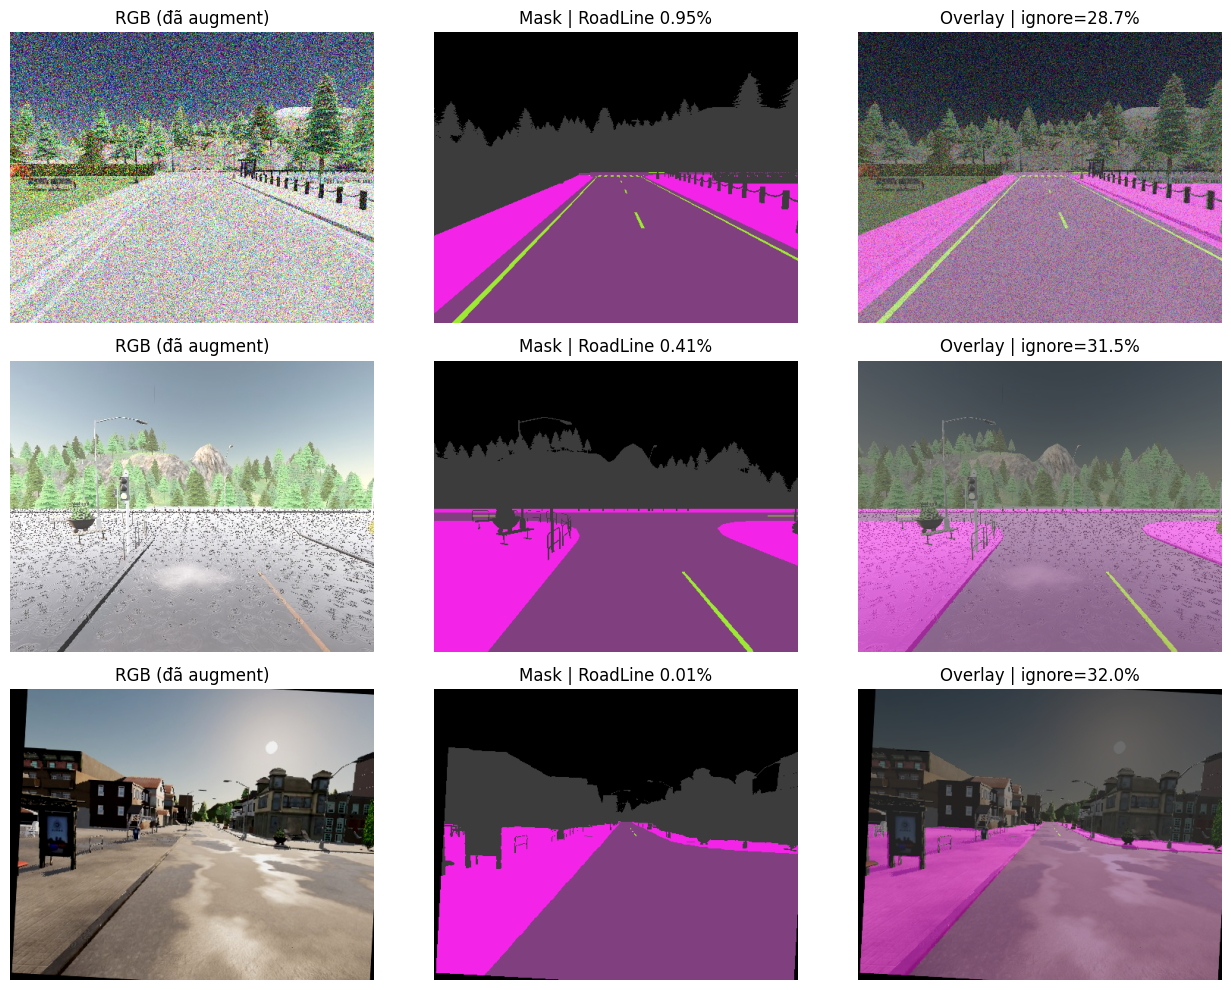

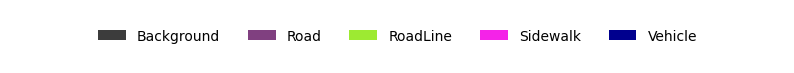

In [13]:
# Kiểm tra mắt thường trước khi train — ảnh và mask phải khớp nhau,
# và vạch kẻ đường phải còn nhìn thấy được sau khi resize.
def denorm(t):
    x = t.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return x.clip(0, 1)

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for r in range(3):
    i = random.randrange(len(train_ds))
    img, msk = train_ds[i]
    m = msk.numpy()
    rl = [j for j, n in enumerate(CLASS_NAMES) if n == "RoadLine"]
    rl_pct = 100 * (m == rl[0]).mean() if rl else 0.0
    axes[r, 0].imshow(denorm(img));   axes[r, 0].set_title("RGB (đã augment)")
    axes[r, 1].imshow(colorize(m));   axes[r, 1].set_title(f"Mask | RoadLine {rl_pct:.2f}%")
    axes[r, 2].imshow(denorm(img));   axes[r, 2].imshow(colorize(m), alpha=0.55)
    axes[r, 2].set_title(f"Overlay | ignore={100*(m==IGNORE_INDEX).mean():.1f}%")
    for c in range(3): axes[r, c].axis("off")
plt.tight_layout(); plt.show()

handles = [plt.Rectangle((0,0),1,1, fc=PALETTE[i]/255) for i in range(NUM_CLASSES)]
plt.figure(figsize=(10, 0.7))
plt.legend(handles, CLASS_NAMES, ncol=7, loc="center", frameon=False)
plt.axis("off"); plt.show()

## 7. Class weights

Với 4 class thay vì 13, phân bố cân hơn hẳn nên weight không cần cực đoan. Vẫn dùng
`sqrt(median_freq / freq)` nhưng clip `[0.5, 4.0]` thay vì `[0.5, 6.0]`: tỉ số nhỏ hơn
giữa class nặng nhất và nhẹ nhất là điều kiện để loss ổn định.

`CLASS_WEIGHT_BOOST` nhân thêm tay cho `RoadLine`. Đây là class quan trọng nhất với
bám làn nhưng mỏng nhất, và median-frequency một mình không đủ ưu tiên nó.

In [14]:
def class_pixel_counts(ds, max_files=None):
    counts = np.zeros(NUM_CLASSES + 1, dtype=np.int64)   # ô cuối = ignore
    n = len(ds) if max_files is None else min(max_files, len(ds))
    if getattr(ds, "blob", None) is None and ds.cache is not None:
        msk = np.load(ds.cache[1], mmap_mode="r")
        n = min(n, len(msk))
        for s in tqdm(range(0, n, 512), desc="đếm pixel", leave=False):
            blk = LABEL_LUT[np.asarray(msk[s:s+512])].ravel()
            blk = np.where(blk == IGNORE_INDEX, NUM_CLASSES, blk)
            counts += np.bincount(blk, minlength=NUM_CLASSES + 1)
    else:
        for i in tqdm(range(n), desc="đếm pixel", leave=False):
            m = ds.get_mask(i).ravel()
            m = np.where(m == IGNORE_INDEX, NUM_CLASSES, m)
            counts += np.bincount(m, minlength=NUM_CLASSES + 1)
    return counts


counts = class_pixel_counts(train_ds)
ignored, counts = counts[NUM_CLASSES], counts[:NUM_CLASSES].astype(np.float64)
total = counts.sum()

present = counts > 0
freq = np.where(present, counts / max(total, 1), 1.0)
w = np.sqrt(np.median(freq[present]) / freq)
for nm, mul in CLASS_WEIGHT_BOOST.items():
    if nm in CLASS_NAMES:
        w[CLASS_NAMES.index(nm)] *= mul
w = np.clip(w, 0.5, WEIGHT_CLIP)
w[~present] = 0.0
class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)

print(f"pixel bị ignore: {100*ignored/(ignored+total):.2f}%\n")
print(f"{'id':>3} {'class':<13} {'%pixel':>9} {'weight':>8}")
for i in range(NUM_CLASSES):
    tag = "" if present[i] else "   <-- VẮNG MẶT"
    print(f"{i:>3} {CLASS_NAMES[i]:<13} {100*counts[i]/total:>8.4f}% {w[i]:>8.3f}{tag}")
print(f"\ntỉ số weight cao nhất / thấp nhất = {w[present].max()/w[present].min():.1f}x")

đếm pixel:   0%|          | 0/50000 [00:00<?, ?it/s]

pixel bị ignore: 26.33%

 id class            %pixel   weight
  0 Background     37.1636%    0.572
  1 Road           49.0762%    0.500
  2 RoadLine        1.5582%    4.000
  3 Sidewalk       12.1514%    1.000
  4 Vehicle         0.0506%    4.000

tỉ số weight cao nhất / thấp nhất = 8.0x


## 8. Model, loss, optimizer, scheduler, EMA

**Loss.** `Dice` giờ chỉ tính trên class nhiệm vụ (`classes=[1..C-1]`). Background
chiếm 60–70% pixel; để nó trong Dice nghĩa là phần lớn giá trị loss đến từ việc dự
đoán đúng bầu trời — thông tin gradient gần như bằng 0 nhưng vẫn làm loãng tín hiệu từ
RoadLine. CE thêm `label_smoothing=0.05` để giảm overconfidence ở biên giữa Road và
RoadLine, nơi nhãn vốn đã mơ hồ ở độ phân giải này.

**EMA.** Trung bình trượt của trọng số qua các step. Thực tế nó gần như luôn cho mIoU
cao hơn model thô 1–2 điểm, đặc biệt khi batch nhỏ và LR còn cao, và chi phí chỉ là một
lần copy tham số mỗi step. Vòng lặp train sẽ đánh giá **cả hai** và giữ cái tốt hơn.

In [ ]:
# Decoder Unet upsample tới ĐÚNG độ phân giải đầu vào, có skip connection từ từng tầng
# encoder -> giữ được cấu trúc mảnh như vạch kẻ đường.
model = smp.Unet(
    encoder_name=ENCODER_NAME,
    encoder_weights="imagenet",
    decoder_attention_type="scse",   # attention nhẹ trên skip, ~0.3M param
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)
if USE_CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)


def unwrap(m):
    # Chỉ còn để tương thích checkpoint cũ lưu từ DataParallel; single-GPU thì là no-op.
    return m.module if isinstance(m, nn.DataParallel) else m


def load_flex(m, sd):
    sd = {k[7:] if k.startswith("module.") else k: v for k, v in sd.items()}
    unwrap(m).load_state_dict(sd)

print(f"{MODEL_ARCH}/{ENCODER_NAME} | "
      f"params: {sum(p.numel() for p in unwrap(model).parameters())/1e6:.2f} M")

# Thử một forward pass để bắt lỗi chia hết cho 32 / OOM NGAY, không phải sau khi
# đã build xong cache và chạy được nửa epoch.
with torch.no_grad(), torch.amp.autocast("cuda", enabled=USE_AMP):
    _x = torch.zeros(2, 3, IMAGE_HEIGHT, IMAGE_WIDTH, device=DEVICE)
    if USE_CHANNELS_LAST:
        _x = _x.to(memory_format=torch.channels_last)
    _y = model(_x)
print(f"forward ok: {tuple(_x.shape)} -> {tuple(_y.shape)}")
assert _y.shape[-2:] == (IMAGE_HEIGHT, IMAGE_WIDTH),     "logits không cùng độ phân giải với input"
del _x, _y; torch.cuda.empty_cache()

In [ ]:
ce_loss = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX,
                              label_smoothing=LABEL_SMOOTHING)
# Dice bỏ qua Background: gradient tập trung vào class nhiệm vụ.
dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True,
                                classes=TASK_CLASS_IDS,
                                ignore_index=IGNORE_INDEX)

def criterion(logits, target):
    return (1 - DICE_WEIGHT) * ce_loss(logits, target) + DICE_WEIGHT * dice_loss(logits, target)


# [v5] Sàn lý thuyết của loss — con số nên có trong báo cáo.
# Label smoothing khiến CE KHÔNG THỂ về 0 kể cả khi dự đoán hoàn hảo: mục tiêu đã bị làm
# mềm nên loss tối thiểu bằng entropy của chính phân phối mềm đó. Biết sàn này thì biểu
# đồ loss phẳng ở cuối là chuyện bình thường, không phải model ngừng học.
if LABEL_SMOOTHING > 0:
    _p = 1 - LABEL_SMOOTHING + LABEL_SMOOTHING / NUM_CLASSES
    _q = LABEL_SMOOTHING / NUM_CLASSES
    CE_FLOOR = float(-_p * np.log(_p) - (NUM_CLASSES - 1) * _q * np.log(_q))
else:
    CE_FLOOR = 0.0
LOSS_FLOOR = (1 - DICE_WEIGHT) * CE_FLOOR
print(f"label_smoothing={LABEL_SMOOTHING}, {NUM_CLASSES} class"
      f"  ->  sàn CE = {CE_FLOOR:.4f}, sàn loss = {LOSS_FLOOR:.4f}")
print(f"   (bản cũ eps=0.05 khoá cứng 0.144 trong loss — đó là lý do nó đứng ở 0.54)")


decay, no_decay = [], []
for n, p in unwrap(model).named_parameters():
    if not p.requires_grad:
        continue
    (no_decay if p.ndim <= 1 or n.endswith(".bias") else decay).append(p)

optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": WEIGHT_DECAY},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=LEARNING_RATE, betas=(0.9, 0.999),
)

TOTAL_STEPS = len(train_loader) * EPOCHS

def lr_at(step):
    if step < WARMUP_STEPS:
        return (step + 1) / WARMUP_STEPS
    p = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    p = min(p, 1.0)
    return MIN_LR_RATIO + (1 - MIN_LR_RATIO) * 0.5 * (1 + np.cos(np.pi * p))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_at)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

# ---- EMA -------------------------------------------------------------------
ema_model = None
if USE_EMA:
    try:
        avg_fn = torch.optim.swa_utils.get_ema_multi_avg_fn(EMA_DECAY)
        ema_model = torch.optim.swa_utils.AveragedModel(
            unwrap(model), multi_avg_fn=avg_fn, use_buffers=True)
    except AttributeError:      # torch cũ không có get_ema_multi_avg_fn
        ema_model = torch.optim.swa_utils.AveragedModel(
            unwrap(model),
            avg_fn=lambda a, c, n: EMA_DECAY * a + (1 - EMA_DECAY) * c,
            use_buffers=True)
    print(f"EMA bật, decay={EMA_DECAY}")

print(f"{TOTAL_STEPS:,} step | warmup {WARMUP_STEPS} | lr {LEARNING_RATE:.1e} -> "
      f"{LEARNING_RATE*MIN_LR_RATIO:.1e}")
print(f"Dice tính trên class: {[CLASS_NAMES[i] for i in TASK_CLASS_IDS]}")

## 8b. Quản lý bộ nhớ

Ba thứ cộng dồn tới trần 30 GB RAM của Kaggle: phân mảnh arena từ augmentation, page
cache của file mmap, và bộ đệm PyTorch. Ở chế độ blob thì hai thứ đầu gần như biến mất,
nhưng giữ lại các hàm này để có số liệu theo dõi trong lúc train.

In [ ]:
try:
    _libc = ctypes.CDLL("libc.so.6")
except OSError:
    _libc = None

_PROC = psutil.Process(os.getpid())


def mem_stats():
    rss = _PROC.memory_info().rss / 1e9
    for p in _PROC.children(recursive=True):
        try:
            rss += p.memory_info().rss / 1e9
        except psutil.Error:
            pass
    vm = psutil.virtual_memory()
    return rss, getattr(vm, "cached", 0) / 1e9, (vm.total - vm.available) / 1e9


def malloc_trim():
    if _libc is not None:
        try:
            _libc.malloc_trim(0)
        except Exception:
            pass


# Không còn file memmap để drop page cache: blob nằm thẳng trong RAM. Việc duy nhất còn
# cần là gom rác Python/CUDA và trả bộ nhớ đã free về hệ điều hành (malloc_trim).
def mem_guard(force=False, verbose=True, tag=""):
    rss, cache, used = mem_stats()
    if force or used > MEM_USED_CEIL_GB:
        gc.collect(); torch.cuda.empty_cache(); malloc_trim()
        rss2, cache2, used2 = mem_stats()
        if verbose:
            print(f"     [mem{tag}] dùng {used:.1f}->{used2:.1f} GB "
                  f"(rss {rss:.1f}->{rss2:.1f}, cache {cache:.1f}->{cache2:.1f})",
                  flush=True)
        return rss2, cache2, used2
    return rss, cache, used


_r, _c, _u = mem_stats()
print(f"RSS {_r:.2f} GB | page cache {_c:.2f} GB | tổng đã dùng {_u:.2f} GB")
print(f"malloc_trim: {'sẵn sàng' if _libc else 'KHÔNG khả dụng'}")

## 9. Vòng lặp huấn luyện

Metric báo cáo mỗi epoch:

| Tên | Ý nghĩa |
|-----|---------|
| `mIoU_task` | **Metric chọn checkpoint.** Trung bình IoU trên class nhiệm vụ (bỏ Background), chỉ tính class thực sự có mặt trong ground-truth val |
| `mIoU_all` | Có cả Background — luôn cao hơn, chỉ để tham chiếu |
| `IoU_drive` | IoU nhị phân của vùng `Road ∪ RoadLine`. Đây là con số gần nhất với "model có bám đúng mặt đường không" |
| `RoadLine` | IoU riêng của vạch kẻ, class quyết định của bài toán |

Lý do không dùng `mIoU_all` để chọn model: Background dễ đến mức IoU của nó luôn > 0.9,
nên nó vừa làm phẳng đường cong vừa che mất việc RoadLine đang tệ dần.

In [ ]:
def update_confmat(cm, pred, target):
    k = target != IGNORE_INDEX
    idx = target[k].to(torch.int64) * NUM_CLASSES + pred[k].to(torch.int64)
    cm += torch.bincount(idx, minlength=NUM_CLASSES ** 2).reshape(NUM_CLASSES, NUM_CLASSES)
    return cm


def iou_from_confmat(cm):
    cmd = cm.double()
    tp = cmd.diag()
    iou = tp / (cmd.sum(0) + cmd.sum(1) - tp).clamp(min=1)
    support = cmd.sum(1)
    return iou.cpu().numpy(), support.cpu().numpy()


def drivable_iou(cm):
    # IoU nhị phân của hợp Road + RoadLine, đọc thẳng từ confusion matrix.
    if not DRIVABLE_IDS:
        return float("nan")
    cmn = cm.cpu().numpy().astype(np.float64)
    d = np.zeros(NUM_CLASSES, bool); d[DRIVABLE_IDS] = True
    tp = cmn[np.ix_(d, d)].sum()
    fp = cmn[np.ix_(~d, d)].sum()
    fn = cmn[np.ix_(d, ~d)].sum()
    return tp / max(tp + fp + fn, 1)


def summarize(cm):
    iou, support = iou_from_confmat(cm)
    seen = support > 0
    task = np.zeros(NUM_CLASSES, bool); task[TASK_CLASS_IDS] = True
    sel = seen & task
    return {
        "miou_task": float(iou[sel].mean()) if sel.any() else 0.0,
        "miou_all":  float(iou[seen].mean()) if seen.any() else 0.0,
        "iou_drive": float(drivable_iou(cm)),
        "iou": iou,
        "support": support,
    }


def run_epoch(loader, train, epoch=None, net=None, tag=None):
    net = net if net is not None else model
    net.train(train)
    total, nstep = 0.0, 0
    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64, device=DEVICE)
    tag = tag or ("train" if train else " val ")
    desc = f"E{epoch+1:02d}/{EPOCHS} [{tag}]" if epoch is not None else tag
    pbar = tqdm(loader, desc=desc, leave=False, unit="b")

    ctx = torch.enable_grad() if train else torch.no_grad()
    images = masks = logits = loss = None
    with ctx:
        for images, masks in pbar:
            images = images.to(DEVICE, non_blocking=True)
            if USE_CHANNELS_LAST:
                images = images.to(memory_format=torch.channels_last)
            masks = masks.to(DEVICE, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = net(images)
                loss = criterion(logits, masks)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                if ema_model is not None:
                    ema_model.update_parameters(unwrap(net))
            else:
                update_confmat(cm, logits.argmax(1), masks)

            total += loss.item(); nstep += 1
            post = {"loss": f"{total/nstep:.4f}",
                    "lr": f"{optimizer.param_groups[0]['lr']:.2e}"}
            if MEM_TRIM_EVERY and nstep % MEM_TRIM_EVERY == 0:
                malloc_trim()
            if MEM_LOG_EVERY and nstep % MEM_LOG_EVERY == 0:
                _rss, _cache, _used = mem_stats()
                post["ram"] = f"{_used:.0f}G"
                print(f"    [{desc} {nstep:>4}] rss={_rss:5.2f}G "
                      f"cache={_cache:5.2f}G dùng={_used:5.2f}G", flush=True)
                if _used > MEM_USED_CEIL_GB:
                    mem_guard(force=True, tag=f" b{nstep}")
            pbar.set_postfix(**post)
    pbar.close()
    del images, masks, logits, loss

    avg = total / max(nstep, 1)
    if train:
        return avg, None
    return avg, summarize(cm)

In [ ]:
HKEYS = ("train_loss", "val_loss", "lane_miou", "miou_task", "miou_all",
         "iou_drive", "lr", "sec")
history = {k: [] for k in HKEYS}
best, best_src, patience = -1.0, "raw", 0
t_start = time.time()

RL = CLASS_NAMES.index("RoadLine") if "RoadLine" in CLASS_NAMES else None

def lane_score(m):
    ids = [i for i in LANE_IDS if m["support"][i] > 0]
    return float(np.mean([m["iou"][i] for i in ids])) if ids else m["miou_task"]

mem_guard(force=True)

for ep in range(EPOCHS):
    t0 = time.time()
    tr_loss, _ = run_epoch(train_loader, True, ep)
    mem_guard(force=True, tag=" tr->val")

    va_loss, m_raw = run_epoch(val_loader, False, ep)
    cand = [("raw", m_raw, va_loss)]
    if ema_model is not None and ep >= 1:
        _, m_ema = run_epoch(val_loader, False, ep, net=ema_model.module, tag=" ema ")
        cand.append(("ema", m_ema, va_loss))

    src, m, _ = max(cand, key=lambda c: lane_score(c[1]))
    score = lane_score(m)
    dt = time.time() - t0
    lr_now = optimizer.param_groups[0]["lr"]

    for k, v in zip(HKEYS, (tr_loss, va_loss, score, m["miou_task"],
                            m["miou_all"], m["iou_drive"], lr_now, dt)):
        history[k].append(v)

    _rss, _cache, _used = mem_guard(force=True, tag=" epoch")
    seen = m["support"] > 0
    worst_pool = [i for i in TASK_CLASS_IDS if seen[i]]
    worst = sorted(worst_pool, key=lambda i: m["iou"][i])[:3]
    rl_txt = f" RoadLine={m['iou'][RL]:.3f}" if RL is not None else ""
    print(f"E{ep+1:02d}/{EPOCHS} train={tr_loss:.4f} val={va_loss:.4f} "
          f"lane={score:.4f}({src}) task={m['miou_task']:.4f} "
          f"drive={m['iou_drive']:.4f}{rl_txt} lr={lr_now:.2e} {dt/60:.1f}m "
          f"ram={_used:.1f}G  | yếu nhất: "
          + ", ".join(f"{CLASS_NAMES[i]}={m['iou'][i]:.2f}" for i in worst))

    if score > best:
        best, best_src, patience = score, src, 0
        sd = (unwrap(model).state_dict() if src == "raw"
              else {k: v for k, v in ema_model.module.state_dict().items()})
        torch.save({
            "epoch": ep,
            "model_state_dict": sd,
            "weights_source": src,
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_lane_miou": best, "best_miou_task": m["miou_task"],
            "collect_fps": COLLECT_FPS, "control_dt": CONTROL_DT,
            "sky_as_class": SKY_AS_CLASS, "sky_id": SKY_ID,
            "lane_ids": LANE_IDS, "task_class_ids": TASK_CLASS_IDS,
            "loss_floor": LOSS_FLOOR,
            "miou_all": m["miou_all"],
            "iou_drivable": m["iou_drive"],
            "per_class_iou": m["iou"].tolist(),
            "num_classes": NUM_CLASSES,
            "class_names": CLASS_NAMES,
            "task_scheme": TASK_SCHEME,
            "model_arch": MODEL_ARCH,
            "encoder_name": ENCODER_NAME,
            "raw_to_train": {int(k): int(v) for k, v in RAW_TO_TRAIN.items()},
            "label_lut": LABEL_LUT.tolist(),
            "ignore_index": IGNORE_INDEX,
            "image_height": IMAGE_HEIGHT,
            "image_width": IMAGE_WIDTH,
            "norm_mean": IMAGENET_MEAN,
            "norm_std": IMAGENET_STD,
        }, CHECKPOINT_PATH)
        print(f"     -> lưu checkpoint ({src}, lane_mIoU={best:.4f})")
    else:
        patience += 1
        if patience >= EARLY_STOP_PATIENCE:
            print(f"Early stop: {EARLY_STOP_PATIENCE} epoch không cải thiện.")
            break

print(f"\nXong. best lane_mIoU = {best:.4f} ({best_src}) "
      f"| tổng {(time.time()-t_start)/60:.1f} phút | {CHECKPOINT_PATH}")

## 10. Biểu đồ huấn luyện

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); # [v5] Vẽ sàn lý thuyết: phần loss KHÔNG THỂ giảm do label smoothing. Không có đường
# này, đoạn phẳng ở cuối trông như model ngừng học; có nó thì thấy rõ còn bao nhiêu
# khoảng cách thật. Rất nên đưa vào báo cáo.
if LOSS_FLOOR > 0:
    ax[0].axhline(LOSS_FLOOR, color="r", ls=":", lw=1.2,
                  label=f"sàn label smoothing = {LOSS_FLOOR:.3f}")
ax[0].legend()
ax[0].set_title("Loss"); ax[0].grid(alpha=.3)

ax[1].plot(history["lane_miou"], label="lane mIoU (Road/Line/Sidewalk)", lw=2)
ax[1].plot(history["miou_task"], label="mIoU (class nhiệm vụ)", ls="-.", alpha=.7)
ax[1].plot(history["miou_all"],  label="mIoU (cả Background)", ls=":")
ax[1].plot(history["iou_drive"], label="IoU vùng đi được", ls="--")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("IoU"); ax[1].legend(fontsize=8)
ax[1].set_title("Validation (Town05)"); ax[1].grid(alpha=.3)

ax[2].plot(history["lr"], c="orange")
ax[2].set_xlabel("epoch"); ax[2].set_ylabel("lr"); ax[2].set_title("LR schedule")
ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"trung bình {np.mean(history['sec']):.0f} s/epoch")

## 11. Đánh giá chi tiết — per-class IoU, confusion matrix, flip-TTA

Confusion matrix cho biết model **nhầm sang đâu**, không chỉ biết nó sai. Với bài toán
bám làn, ô cần nhìn đầu tiên là `RoadLine -> Road`: đó là vạch kẻ bị nuốt vào mặt
đường, lỗi trực tiếp làm bộ điều khiển mất tham chiếu làn.

Flip-TTA (trung bình logits của ảnh gốc và ảnh lật ngang) thường thêm 0.5–1 điểm mIoU
miễn phí. Nó chỉ dùng lúc đánh giá/inference, không dùng lúc train.

In [ ]:
USE_TTA = True

ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
load_flex(model, ckpt["model_state_dict"])
model.eval()
print(f"nạp checkpoint epoch {ckpt['epoch']+1} ({ckpt['weights_source']}), "
      f"lane_mIoU={ckpt.get('best_lane_miou', float('nan')):.4f} "
      f"mIoU_task={ckpt['best_miou_task']:.4f}")


def predict_logits(net, x):
    with torch.amp.autocast("cuda", enabled=USE_AMP):
        out = net(x)
        if USE_TTA:
            out = out + torch.flip(net(torch.flip(x, dims=[3])), dims=[3])
    return out


cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64, device=DEVICE)
with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="eval val"):
        images = images.to(DEVICE, non_blocking=True)
        if USE_CHANNELS_LAST:
            images = images.to(memory_format=torch.channels_last)
        masks = masks.to(DEVICE, non_blocking=True)
        update_confmat(cm, predict_logits(model, images).argmax(1), masks)

m = summarize(cm)
iou, support = m["iou"], m["support"]
cm_np = cm.cpu().numpy()
tp = np.diag(cm_np)
prec = tp / np.maximum(cm_np.sum(0), 1)
rec  = tp / np.maximum(cm_np.sum(1), 1)
seen = support > 0

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
cols = [PALETTE[i]/255 for i in range(NUM_CLASSES)]
ax[0].bar(range(NUM_CLASSES), iou, color=cols, edgecolor="black", lw=.5)
for i, v in enumerate(iou):
    ax[0].text(i, v + .02, f"{v:.2f}", ha="center", fontsize=9)
ax[0].set_xticks(range(NUM_CLASSES))
ax[0].set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)
ax[0].set_ylim(0, 1.05); ax[0].set_ylabel("IoU"); ax[0].grid(axis="y", alpha=.3)
ax[0].set_title(f"Per-class IoU — Town05 (TTA={USE_TTA})")

cmn = cm_np / np.maximum(cm_np.sum(1, keepdims=True), 1)
im = ax[1].imshow(cmn, cmap="Blues", vmin=0, vmax=1)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cmn[i, j] > 0.01:
            ax[1].text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                       fontsize=7, color="white" if cmn[i,j] > .5 else "black")
ax[1].set_xticks(range(NUM_CLASSES)); ax[1].set_yticks(range(NUM_CLASSES))
ax[1].set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)
ax[1].set_yticklabels(CLASS_NAMES, fontsize=9)
ax[1].set_xlabel("dự đoán"); ax[1].set_ylabel("thực tế")
ax[1].set_title("Confusion matrix (chuẩn hoá theo hàng)")
plt.colorbar(im, ax=ax[1], fraction=.046)
plt.tight_layout(); plt.show()

print(f"\n{'class':<14}{'IoU':>8}{'Prec':>8}{'Recall':>8}{'%pixel GT':>12}")
for i in range(NUM_CLASSES):
    mark = "" if seen[i] else "  (vắng mặt)"
    print(f"{CLASS_NAMES[i]:<14}{iou[i]:>8.4f}{prec[i]:>8.4f}{rec[i]:>8.4f}"
          f"{100*support[i]/support.sum():>11.3f}%{mark}")

print(f"\nmIoU (class nhiệm vụ)   : {m['miou_task']:.4f}   <-- chỉ số chính")
print(f"mIoU (cả Background)    : {m['miou_all']:.4f}")
print(f"IoU vùng đi được        : {m['iou_drive']:.4f}")
print(f"Pixel accuracy          : {tp.sum()/max(cm_np.sum(),1):.4f}")

print("\nNhầm lẫn lớn nhất (bỏ đường chéo):")
off = cmn.copy(); np.fill_diagonal(off, 0)
for gt, pr in zip(*np.unravel_index(np.argsort(off, axis=None)[::-1][:6], off.shape)):
    if off[gt, pr] <= 0:
        continue
    print(f"  {CLASS_NAMES[gt]:<12} -> bị đoán thành {CLASS_NAMES[pr]:<12} {100*off[gt,pr]:>5.1f}%")

# ============================================================
# [v5] BẢNG SỐ CHO BÁO CÁO — ba tầng, ghi rõ tầng nào gồm class nào
# ============================================================
# Chỉ ghi một con số mIoU trong báo cáo là mập mờ: Background (đã gộp cả bầu trời) là
# vùng lớn và dễ nên mIoU_all luôn cao hơn mIoU_task đáng kể. Ghi cả ba tầng thì người
# đọc kiểm chứng được con số nào đo cái gì.
_iou = m["iou"]
_tiers = [
    ("lane  (Road/RoadLine/Sidewalk)",  LANE_IDS),
    ("task  (mọi class trừ nền/trời)",  TASK_CLASS_IDS),
    ("all   (kể cả Background)",        list(range(NUM_CLASSES))),
]
print("\n" + "=" * 60)
print(f"{'tầng':<34}{'mIoU':>9}   class")
for _nm, _ids in _tiers:
    _v = [_iou[i] for i in _ids if m["support"][i] > 0]
    print(f"{_nm:<34}{np.mean(_v):>9.4f}   {[CLASS_NAMES[i] for i in _ids]}")
print("=" * 60)
print(f"{'IoU vùng đi được (Road ∪ RoadLine)':<34}{m['iou_drive']:>9.4f}")
print(f"{'Pixel accuracy':<34}{float(tp.sum()/max(cm_np.sum(),1)):>9.4f}")
if SKY_ID is not None:
    print(f"\nSky IoU = {_iou[SKY_ID]:.4f} trên "
          f"{100*support[SKY_ID]/support.sum():.1f}% pixel.")
    print("Bầu trời là vùng lớn và đồng nhất nên IoU rất cao — đó là lý do nó bị tách")
    print("khỏi mIoU_task thay vì để nó kéo trung bình lên.")

## 12. Trực quan hóa dự đoán

In [ ]:
N = 4
fig, axes = plt.subplots(N, 5, figsize=(21, 3.4 * N))
leaks = []
with torch.no_grad():
    for r in range(N):
        i = random.randrange(len(val_ds))
        img, gt = val_ds[i]
        x = img.unsqueeze(0).to(DEVICE)
        if USE_CHANNELS_LAST:
            x = x.to(memory_format=torch.channels_last)
        pred = predict_logits(model, x).argmax(1)[0].cpu().numpy().astype(np.uint8)
        g = gt.numpy()

        # [v5] Bản cũ tính err = (pred != g) & (g != IGNORE_INDEX) nên nó GIẤU đúng vùng
        # đang sai — cả bầu trời bị loại khỏi phép đo, và bạn thấy "Sai 0.8%" trong khi
        # nửa trên ảnh loang lổ hồng. Giờ vùng ignore vẽ xám để thấy nó rộng bao nhiêu.
        err = (pred != g) & (g != IGNORE_INDEX)
        ign = (g == IGNORE_INDEX)
        vis = np.zeros((*err.shape, 3))
        vis[..., 0] = err.astype(float)
        vis[ign] = [0.75, 0.75, 0.75]

        # Chỉ số an toàn thật sự cho bộ điều khiển: model nói "đi được" ở nơi ground
        # truth nói không. Trước khi sửa nhãn con số này ~10-20% (cả vùng trời), sau khi
        # bầu trời được giám sát (gộp vào Background) phải xuống dưới 0.5%.
        leak = (np.isin(pred, DRIVABLE_IDS) & ~np.isin(g, DRIVABLE_IDS) & ~ign)
        leaks.append(leak.mean())

        axes[r, 0].imshow(denorm(img));    axes[r, 0].set_title("RGB")
        axes[r, 1].imshow(colorize(g));    axes[r, 1].set_title("Ground truth")
        axes[r, 2].imshow(colorize(pred)); axes[r, 2].set_title("Dự đoán")
        axes[r, 3].imshow(1 - vis)
        axes[r, 3].set_title(f"Sai {100*err.mean():.1f}%  |  ignore {100*ign.mean():.1f}%")
        axes[r, 4].imshow(leak, cmap="Reds")
        axes[r, 4].set_title(f"Đoán nhầm 'đi được': {100*leak.mean():.2f}%")
        for c in range(5):
            axes[r, c].axis("off")

handles = [plt.Rectangle((0, 0), 1, 1, fc=PALETTE[i] / 255) for i in range(NUM_CLASSES)]
fig.legend(handles, CLASS_NAMES, ncol=NUM_CLASSES, loc="lower center", frameon=False)
plt.tight_layout(); plt.show()

print(f"Rò rỉ vùng đi được trung bình: {100*np.mean(leaks):.3f}% pixel/ảnh")
print(f"Vùng ignore còn lại: chỉ là viền do A.Affine sinh ra (thường 0.0-0.5%).")
print("Nếu ignore vẫn ~25%: bạn đang để IGNORE_UNLABELED=True — chạy lại §1 và §3.")


## 13. Ghi chú cho bước Imitation Learning

Checkpoint lưu `state_dict` **không có** tiền tố `module.`, cùng `label_lut` đầy đủ để
bạn tái tạo chính xác không gian nhãn ở phía IL:

```python
ck = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
seg = smp.Unet("resnet34", encoder_weights=None, decoder_attention_type="scse",
               in_channels=3, classes=ck["num_classes"])
seg.load_state_dict(ck["model_state_dict"]); seg.eval()

CLASS_NAMES = ck["class_names"]          # ví dụ: Background/Road/RoadLine/Sidewalk/...
ROAD_ID     = CLASS_NAMES.index("Road")
LINE_ID     = CLASS_NAMES.index("RoadLine")
```

**Số class đã đổi** (13 → 4: `Background, Road, RoadLine, Sidewalk`). Ba nơi phải khớp
byte-for-byte với `label_lut` trong checkpoint này, nếu không model sẽ nhận sai kênh mà
KHÔNG có lỗi nào báo (shape vẫn khớp):

| Nơi | Thứ phải sửa |
|-----|--------------|
| `behavior_cloning/train_il.ipynb` | `CLASS_NAMES`, `RAW_TO_TRAIN`, `PALETTE` (§2b kiểm tra tự động) |
| `data_collection/carla_collector/schema.py` | `RAW_TO_TRAIN_LANE` — nguồn sự thật cho collector và DRL |
| `drl_training/policy/backbone.py` | `NUM_CLASSES` (số kênh vào của conv đầu tiên) |

Tiền xử lý ở IL phải **giống hệt** nhánh validation: resize `INTER_LINEAR` về
`(image_height, image_width)`, rồi `Normalize(norm_mean, norm_std)`. Lệch bước này là
nguyên nhân phổ biến nhất khiến model seg chạy tốt trong notebook train nhưng dự đoán
nhiễu khi ghép vào IL.

---

### Nếu muốn đẩy chỉ số cao hơn nữa

Thứ tự theo tác động giảm dần:

1. **Chạy trọn lịch cosine.** Lần trước bạn early-stop ở epoch 12/40, LR mới giảm 18%.
   Segmentation kiếm phần lớn mIoU ở một phần ba cuối khi LR đã thấp và model tinh chỉnh
   biên giới class. `EPOCHS` và `EARLY_STOP_PATIENCE` giờ đã khớp nhau — đừng đặt lại
   patience thấp hơn ~EPOCHS/2.
2. **Đã áp dụng ở v6: `TASK_SCHEME = "lane4"` + gộp bầu trời vào Background.** 3 class
   nhiệm vụ còn lại đều là vùng lớn, liên tục, dễ học, và không còn class nào có IoU ≈ 0
   kéo trung bình xuống.
3. **Cắt bỏ phần trời.** Ở camera gắn trên nóc xe, ~25–30% phía trên ảnh không bao giờ
   chứa mặt đường. Crop trước khi resize cho thêm ~1.4× độ phân giải hiệu dụng trên vùng
   quan trọng, miễn phí về tính toán. Phải áp dụng đồng bộ ở notebook IL.
4. **`ENCODER_NAME = "efficientnet-b2"`** hoặc `resnet50` nếu VRAM còn dư sau khi đã
   giảm batch.
5. **Thu lại dữ liệu CÓ NPC** rồi mới bật `lane5` (Pedestrian) hoặc thêm Vehicle. Với
   dataset không NPC như hiện tại, không loss weight nào cứu được một class 0% pixel.

### Nếu vẫn OOM

Theo thứ tự: `BATCH_SIZE = 8` → `decoder_attention_type=None` → `TRAIN_STRIDE = 3`.
Batch 8 với BatchNorm bắt đầu hơi nhiễu; nếu buộc phải xuống thấp hơn nữa thì đổi
`ENCODER_NAME = "resnet18"` thay vì hạ batch tiếp.